# Task 02 — Qwen architecture and Hugging Face baseline

**Purpose:** load `Qwen/Qwen3-0.6B`, check its architecture facts against
live tensors, and record a deterministic float generation baseline.

**Lesson:** [docs/tasks/02-qwen-architecture-and-baseline.html](../docs/tasks/02-qwen-architecture-and-baseline.html)

**Environment:** the Task 01 environment (`.venv`, Python 3.11). CPU only,
float32. The model download (~1.4 GB) goes to the external drive
`/Volumes/T9`, not your home folder.

Run cells top to bottom. **The setup cell must run first** — it points the
Hugging Face cache at the external drive before `transformers` loads.

## Part 1 — Setup

Checks the drive, sets the cache location, prepares `results/`.
If this cell fails, fix the message it prints before going on.

In [1]:
import json
import os
import sys
import time
from pathlib import Path

# The cache location must be set before transformers is imported anywhere.
assert "transformers" not in sys.modules, (
    "transformers was already imported. Restart the kernel and run this cell first."
)
assert Path("/Volumes/T9").exists(), (
    "/Volumes/T9 is not mounted. Connect the drive, check `df -h /Volumes/T9`, rerun."
)

HF_HOME = Path("/Volumes/T9/qualcomm-edge-slm-lab/hf-home")
HF_HOME.mkdir(parents=True, exist_ok=True)
os.environ["HF_HOME"] = str(HF_HOME)

REPO = Path.cwd().resolve()
if REPO.name == "notebooks":
    REPO = REPO.parent
assert (REPO / "CLAUDE.md").exists(), f"Not inside the repo. cwd = {Path.cwd()}"
RESULTS = REPO / "results"
RESULTS.mkdir(exist_ok=True)

print("HF cache   :", os.environ["HF_HOME"])
print("results dir:", RESULTS)
print("setup ok")

HF cache   : /Volumes/T9/qualcomm-edge-slm-lab/hf-home
results dir: /Users/chayut/projects/qualcomm-edge-slm-lab/results
setup ok


## Part 2 — Load the model

Float32 on CPU: the exact-precision baseline everything later is compared
against. `attn_implementation="eager"` makes the model materialize the
attention weight matrix, so `output_attentions=True` returns real tensors.
The default (`sdpa`) is faster but returns `None` there.

First run downloads ~1.4 GB. Watch the load time it prints.

In [2]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

MODEL_ID = "Qwen/Qwen3-0.6B"

t0 = time.time()
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    dtype=torch.float32,
    attn_implementation="eager",
)
model.eval()
load_s = time.time() - t0

param_device = next(model.parameters()).device
print(f"loaded {MODEL_ID} in {load_s:.1f} s")
print("dtype :", model.dtype)
print("device:", param_device)
assert model.dtype == torch.float32
assert param_device.type == "cpu" 

/Users/chayut/projects/qualcomm-edge-slm-lab/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


loaded Qwen/Qwen3-0.6B in 16.6 s
dtype : torch.float32
device: cpu


## Part 3 — Config facts

Every value the lesson's Section 5 table claims, asserted against the
real `config.json`. Saved to `results/02_config_summary.json`.

In [3]:
EXPECTED_CONFIG = {
    "num_hidden_layers": 28,
    "hidden_size": 1024,
    "num_attention_heads": 16,
    "num_key_value_heads": 8,
    "head_dim": 128,
    "intermediate_size": 3072,
    "vocab_size": 151936,
    "rope_theta": 1000000,
    "max_position_embeddings": 40960,
    "tie_word_embeddings": True,
}

config_summary = {}
for field, want in EXPECTED_CONFIG.items():
    got = getattr(model.config, field)
    config_summary[field] = got
    assert got == want, f"{field}: config says {got}, lesson claims {want}"
    print(f"{field:26s} = {got}")

# The head math the lesson warns about:
naive = model.config.hidden_size // model.config.num_attention_heads
print(f"\nhidden_size / num_attention_heads = {naive}  <- NOT the head_dim")
print(f"head_dim (explicit)               = {model.config.head_dim}")

(RESULTS / "02_config_summary.json").write_text(json.dumps(config_summary, indent=2))
print("\nall config assertions passed; saved 02_config_summary.json")

num_hidden_layers          = 28
hidden_size                = 1024
num_attention_heads        = 16
num_key_value_heads        = 8
head_dim                   = 128
intermediate_size          = 3072
vocab_size                 = 151936
rope_theta                 = 1000000
max_position_embeddings    = 40960
tie_word_embeddings        = True

hidden_size / num_attention_heads = 64  <- NOT the head_dim
head_dim (explicit)               = 128

all config assertions passed; saved 02_config_summary.json


## Part 4 — Where the parameters live

Counts parameters per component. Inspect the table: the embedding table
alone is about a quarter of the model. The tied-weights check proves the
LM head is literally the same tensor object as the embedding (`is`
compares identity, not values).

In [4]:
buckets = {"embedding": 0, "attention": 0, "mlp": 0, "norms": 0}
for name, p in model.named_parameters():
    if "embed_tokens" in name:
        buckets["embedding"] += p.numel()
    elif "self_attn" in name:
        buckets["attention"] += p.numel()
    elif "mlp" in name:
        buckets["mlp"] += p.numel()
    else:
        buckets["norms"] += p.numel()

total = sum(p.numel() for p in model.parameters())
for comp, n in buckets.items():
    print(f"{comp:10s} {n:12,d}  ({100 * n / total:5.1f} %)")
print(f"{'total':10s} {total:12,d}")

tied = model.lm_head.weight is model.model.embed_tokens.weight
print(f"\nlm_head.weight is embed_tokens.weight: {tied}")
assert tied, "Expected tied embeddings for Qwen3-0.6B"
assert 5.5e8 < total < 6.5e8, f"total {total:,} outside the ~0.6B range"

# The 'Think before running' numbers: KV cache cost per token, per layer.
kv_now = 2 * model.config.num_key_value_heads * model.config.head_dim
kv_full = 2 * model.config.num_attention_heads * model.config.head_dim
print(f"KV numbers per token per layer, 8 KV heads : {kv_now}")
print(f"same with 16 KV heads (no GQA)             : {kv_full}")

(RESULTS / "02_parameter_summary.json").write_text(json.dumps(
    {"per_component": buckets, "total": total, "tied_embeddings": tied,
     "kv_numbers_per_token_per_layer": kv_now}, indent=2))
print("saved 02_parameter_summary.json")

embedding   155,582,464  ( 26.1 %)
attention   176,167,936  ( 29.6 %)
mlp         264,241,152  ( 44.3 %)
norms            58,368  (  0.0 %)
total       596,049,920

lm_head.weight is embed_tokens.weight: True
KV numbers per token per layer, 8 KV heads : 2048
same with 16 KV heads (no GQA)             : 4096
saved 02_parameter_summary.json


## Part 5 — One decoder block up close

Prints layer 0 and asserts every weight shape. PyTorch `Linear` stores its
weight as `[out_features, in_features]`, so `q_proj` shows `(2048, 1024)`:
in 1024, out 2048 = 16 heads × 128.

In [5]:
layer0 = model.model.layers[0]
print(layer0)

EXPECTED_SHAPES = {
    "self_attn.q_proj.weight": (2048, 1024),
    "self_attn.k_proj.weight": (1024, 1024),
    "self_attn.v_proj.weight": (1024, 1024),
    "self_attn.o_proj.weight": (1024, 2048),
    "self_attn.q_norm.weight": (128,),
    "self_attn.k_norm.weight": (128,),
    "mlp.gate_proj.weight": (3072, 1024),
    "mlp.up_proj.weight": (3072, 1024),
    "mlp.down_proj.weight": (1024, 3072),
}
actual = {n: tuple(p.shape) for n, p in layer0.named_parameters()}
print()
for name, want in EXPECTED_SHAPES.items():
    got = actual[name]
    assert got == want, f"{name}: got {got}, expected {want}"
    print(f"{name:26s} {got}")
print("\nall layer-0 shape assertions passed")

Qwen3DecoderLayer(
  (self_attn): Qwen3Attention(
    (q_proj): Linear(in_features=1024, out_features=2048, bias=False)
    (k_proj): Linear(in_features=1024, out_features=1024, bias=False)
    (v_proj): Linear(in_features=1024, out_features=1024, bias=False)
    (o_proj): Linear(in_features=2048, out_features=1024, bias=False)
    (q_norm): Qwen3RMSNorm((128,), eps=1e-06)
    (k_norm): Qwen3RMSNorm((128,), eps=1e-06)
  )
  (mlp): Qwen3MLP(
    (gate_proj): Linear(in_features=1024, out_features=3072, bias=False)
    (up_proj): Linear(in_features=1024, out_features=3072, bias=False)
    (down_proj): Linear(in_features=3072, out_features=1024, bias=False)
    (act_fn): SiLUActivation()
  )
  (input_layernorm): Qwen3RMSNorm((1024,), eps=1e-06)
  (post_attention_layernorm): Qwen3RMSNorm((1024,), eps=1e-06)
)

self_attn.q_proj.weight    (2048, 1024)
self_attn.k_proj.weight    (1024, 1024)
self_attn.v_proj.weight    (1024, 1024)
self_attn.o_proj.weight    (1024, 2048)
self_attn.q_norm.weight

## Part 6 — Shape probe on a real forward pass

`run_shape_probe(seq_len)` feeds real tokens through the model and reads
six tensor shapes from live outputs, asserting each against the formula.

Each run is written to `results/02_shape_comparison.json` **immediately**,
so a kernel restart cannot lose it. Rerunning a sequence length replaces
that entry.

In [6]:
def get_kv(cache, layer_idx):
    """Read K and V for one layer. Handles old and new transformers cache APIs."""
    if hasattr(cache, "layers"):  # transformers >= 4.56
        return cache.layers[layer_idx].keys, cache.layers[layer_idx].values
    if hasattr(cache, "key_cache"):  # older versions
        return cache.key_cache[layer_idx], cache.value_cache[layer_idx]
    return cache[layer_idx][0], cache[layer_idx][1]


PROBE_TEXT = (
    "Snapdragon phones run small language models directly on the neural "
    "processing unit, so tokens appear without any network connection at all."
)
SHAPE_FILE = RESULTS / "02_shape_comparison.json"


def run_shape_probe(seq_len):
    ids = tokenizer(PROBE_TEXT, return_tensors="pt").input_ids
    assert ids.shape[1] >= seq_len, (
        f"Probe text has only {ids.shape[1]} tokens. Pick SEQ_LEN <= {ids.shape[1]}."
    )
    ids = ids[:, :seq_len]
    with torch.no_grad():
        out = model(ids, output_attentions=True, output_hidden_states=True, use_cache=True)
    k, v = get_kv(out.past_key_values, 0)
    got = {
        "input_ids": list(ids.shape),
        "hidden_state_embedding": list(out.hidden_states[0].shape),
        "attention_weights_layer0": list(out.attentions[0].shape),
        "k_layer0": list(k.shape),
        "v_layer0": list(v.shape),
        "logits": list(out.logits.shape),
    }
    expected = {
        "input_ids": [1, seq_len],
        "hidden_state_embedding": [1, seq_len, 1024],
        "attention_weights_layer0": [1, 16, seq_len, seq_len],
        "k_layer0": [1, 8, seq_len, 128],
        "v_layer0": [1, 8, seq_len, 128],
        "logits": [1, seq_len, 151936],
    }
    for name, want in expected.items():
        assert got[name] == want, f"{name}: got {got[name]}, expected {want}"
    # persist right away so a restart cannot lose this run
    runs = json.loads(SHAPE_FILE.read_text()) if SHAPE_FILE.exists() else {}
    runs[str(seq_len)] = got
    SHAPE_FILE.write_text(json.dumps(runs, indent=2))
    print(f"seq_len={seq_len}: all 6 shape assertions passed; saved to {SHAPE_FILE.name}")
    return ids, out


print("run_shape_probe is defined")

run_shape_probe is defined


## PARAMETER — sequence length

Run this cell once as it is (`SEQ_LEN = 8`). Then change `SEQ_LEN`
(try `16`) and run it again. The table below the run compares every
recorded sequence length.

Inspect: which dimensions follow `SEQ_LEN`, and which never move? The
fixed ones (16, 8, 128, 1024, 151936) are exactly what NPU compilation
freezes later.

In [11]:
SEQ_LEN = 16  # PARAMETER: change me (for example to 16) and rerun this cell

probe_ids, probe_out = run_shape_probe(SEQ_LEN)

runs = json.loads(SHAPE_FILE.read_text())
seq_lens = sorted(runs, key=int)
print(f"\nrecorded sequence lengths: {seq_lens}\n")
header = f"{'tensor':26s}" + "".join(f"  S={s:<18s}" for s in seq_lens)
print(header)
for tensor_name in runs[seq_lens[0]]:
    row = f"{tensor_name:26s}"
    for s in seq_lens:
        row += f"  {str(runs[s][tensor_name]):<20s}"
    print(row)

seq_len=16: all 6 shape assertions passed; saved to 02_shape_comparison.json

recorded sequence lengths: ['8', '16']

tensor                      S=8                   S=16                
input_ids                   [1, 8]                [1, 16]             
hidden_state_embedding      [1, 8, 1024]          [1, 16, 1024]       
attention_weights_layer0    [1, 16, 8, 8]         [1, 16, 16, 16]     
k_layer0                    [1, 8, 8, 128]        [1, 8, 16, 128]     
v_layer0                    [1, 8, 8, 128]        [1, 8, 16, 128]     
logits                      [1, 8, 151936]        [1, 16, 151936]     


## Part 7 — See the attention

Left: attention weights of layer 0, head 0 for your probe tokens. Each
row shows where one token looks. The upper-right triangle is empty —
that is the causal mask: no token may see the future. The first column is
often dark; many heads park attention on the first token.

Right: the GQA head counts. 16 query heads share 8 K/V heads.

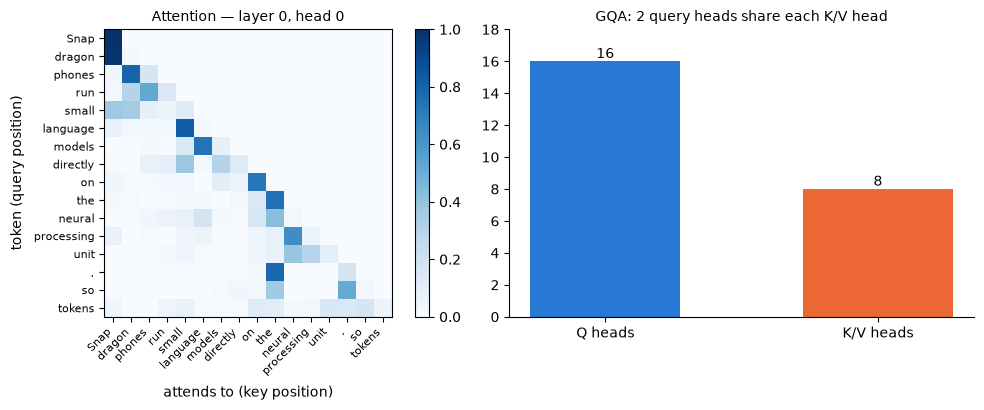

In [12]:
import matplotlib.pyplot as plt

tokens = [tokenizer.decode([t]) for t in probe_ids[0]]
attn = probe_out.attentions[0][0, 0].detach().numpy()  # layer 0, head 0

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))

im = ax1.imshow(attn, cmap="Blues", vmin=0.0)
ax1.set_xticks(range(len(tokens)), tokens, rotation=45, ha="right", fontsize=8)
ax1.set_yticks(range(len(tokens)), tokens, fontsize=8)
ax1.set_xlabel("attends to (key position)")
ax1.set_ylabel("token (query position)")
ax1.set_title("Attention — layer 0, head 0", fontsize=10)
fig.colorbar(im, ax=ax1, fraction=0.046)

bars = ax2.bar(["Q heads", "K/V heads"], [16, 8],
               color=["#2a78d6", "#eb6834"], width=0.55)
ax2.bar_label(bars)
ax2.set_ylim(0, 18)
ax2.set_title("GQA: 2 query heads share each K/V head", fontsize=10)
ax2.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

## Part 8 — Deterministic baseline generation

Greedy decoding: at every step, take the single highest-scoring token.
No sampling, no randomness — the run is repeated twice and asserted
identical. `enable_thinking=False` turns off Qwen3's thinking mode, so
no `<think>` block appears.

This exact output is the float baseline later tasks compare against.

In [13]:
messages = [{"role": "user",
             "content": "In one sentence, what does a neural processing unit do?"}]
prompt_ids = tokenizer.apply_chat_template(
    messages,
    add_generation_prompt=True,
    enable_thinking=False,
    return_tensors="pt",
)
MAX_NEW_TOKENS = 48


def greedy_generate():
    with torch.no_grad():
        out_ids = model.generate(
            prompt_ids,
            attention_mask=torch.ones_like(prompt_ids),
            max_new_tokens=MAX_NEW_TOKENS,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )
    return tokenizer.decode(out_ids[0, prompt_ids.shape[1]:], skip_special_tokens=True)


t0 = time.time()
text_run1 = greedy_generate()
first_run_s = time.time() - t0
text_run2 = greedy_generate()

assert text_run1 == text_run2, "The two greedy runs differ. Determinism is broken."
assert "<think>" not in text_run1, "Thinking mode leaked into the output."
print(f"generated {MAX_NEW_TOKENS} tokens in {first_run_s:.1f} s (run 1)")
print("both runs identical:", text_run1 == text_run2)
print("\n--- baseline output ---")
print(text_run1)

(RESULTS / "02_generation_baseline.json").write_text(json.dumps({
    "model_id": MODEL_ID,
    "dtype": "float32",
    "messages": messages,
    "enable_thinking": False,
    "max_new_tokens": MAX_NEW_TOKENS,
    "text": text_run1,
    "runs_identical": True,
    "first_run_seconds": round(first_run_s, 2),
}, indent=2))
print("\nsaved 02_generation_baseline.json")

generated 48 tokens in 0.9 s (run 1)
both runs identical: True

--- baseline output ---
A neural processing unit processes information from sensory inputs and generates outputs for decision-making and action execution.

saved 02_generation_baseline.json


## Final summary

Reruns every check from disk and live objects, then writes
`results/02_summary.json`. All checks must be `true` for the task gate.
If `two_seq_lens_compared` is `false`, go back to the PARAMETER cell,
change `SEQ_LEN`, and rerun it — then rerun this cell.

In [14]:
shape_runs = json.loads(SHAPE_FILE.read_text()) if SHAPE_FILE.exists() else {}
gen_file = RESULTS / "02_generation_baseline.json"
gen = json.loads(gen_file.read_text()) if gen_file.exists() else {}

CHECKS = {
    "model_loaded_float32_cpu": model.dtype == torch.float32,
    "config_matches_pinned_facts": all(
        getattr(model.config, f) == w for f, w in EXPECTED_CONFIG.items()),
    "embedding_and_lm_head_tied": model.lm_head.weight is model.model.embed_tokens.weight,
    "total_params_in_range": 5.5e8 < sum(p.numel() for p in model.parameters()) < 6.5e8,
    "layer0_shapes_correct": all(
        tuple(dict(layer0.named_parameters())[n].shape) == w
        for n, w in EXPECTED_SHAPES.items()),
    "shape_runs_saved": len(shape_runs) >= 1,
    "two_seq_lens_compared": len(shape_runs) >= 2,
    "generation_deterministic": gen.get("runs_identical") is True,
    "config_summary_saved": (RESULTS / "02_config_summary.json").exists(),
    "parameter_summary_saved": (RESULTS / "02_parameter_summary.json").exists(),
}

ARTIFACTS = sorted(str(p.relative_to(REPO)) for p in RESULTS.glob("02_*.json"))

for check_name, ok in CHECKS.items():
    print(f"{'PASS' if ok else 'FAIL'}  {check_name}")
print("\nsaved artifacts:")
for a in ARTIFACTS:
    print(" ", a)

(RESULTS / "02_summary.json").write_text(json.dumps({
    "task": 2,
    "checks": CHECKS,
    "shape_seq_lens": sorted(shape_runs, key=int),
    "artifacts": ARTIFACTS,
    "written_at": time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime()),
}, indent=2))

failures = [c for c, ok in CHECKS.items() if not ok]
assert not failures, (
    f"Checks failing: {failures}. "
    "If it is two_seq_lens_compared: change SEQ_LEN in the PARAMETER cell, "
    "rerun it, then rerun this cell."
)
print("\nALL CHECKS PASS — save the notebook and say: Review my current task.")

PASS  model_loaded_float32_cpu
PASS  config_matches_pinned_facts
PASS  embedding_and_lm_head_tied
PASS  total_params_in_range
PASS  layer0_shapes_correct
PASS  shape_runs_saved
PASS  two_seq_lens_compared
PASS  generation_deterministic
PASS  config_summary_saved
PASS  parameter_summary_saved

saved artifacts:
  results/02_config_summary.json
  results/02_generation_baseline.json
  results/02_parameter_summary.json
  results/02_shape_comparison.json
  results/02_summary.json

ALL CHECKS PASS — save the notebook and say: Review my current task.
